In [0]:
from pyspark.sql import functions as F

training_df = spark.table("claims_dev.gold.training_dataset")

display(
    training_df.select(
        "image_name",
        "damage_label",
        "file_size_kb"
    )
)

image_name,damage_label,file_size_kb
0-ok (3).png,ok,1783.96
1-minor (3).png,minor,1559.56
10-ok (3).png,ok,1550.73
11-ok (3).png,ok,1513.89
12-ok (3).png,ok,1367.29
13-ok (3).png,ok,1348.33
14-ok (3).png,ok,1288.09
15-ok (3).png,ok,1387.3
16-minor (3).png,minor,1617.29
17-minor (3).png,minor,1332.68


In [0]:
training_df.groupBy("damage_label").count().display()

damage_label,count
major,18
minor,21
ok,17


In [0]:
sample_row = (
    training_df
    .select("image_name", "damage_label", "content")
    .limit(1)
    .collect()[0]
)

sample_row["image_name"], sample_row["damage_label"], len(sample_row["content"])

('0-ok (3).png', 'ok', 1826771)

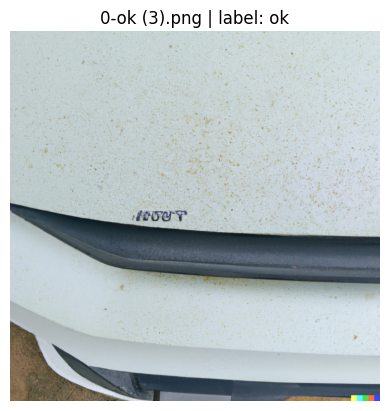

In [0]:
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

image_bytes = sample_row["content"]

img = Image.open(BytesIO(image_bytes)).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.title(f"{sample_row['image_name']} | label: {sample_row['damage_label']}")
plt.show()

In [0]:
import numpy as np
import pandas as pd
from PIL import Image
from io import BytesIO

IMAGE_SIZE = (224, 224)

rows = (
    training_df
    .select("image_name", "damage_label", "content")
    .collect()
)

images = []
labels = []
image_names = []

for row in rows:
    img = Image.open(BytesIO(row["content"])).convert("RGB")
    img = img.resize(IMAGE_SIZE)

    img_array = np.array(img) / 255.0

    images.append(img_array)
    labels.append(row["damage_label"])
    image_names.append(row["image_name"])

X = np.array(images)
y = np.array(labels)

X.shape, y.shape, sorted(set(y))

((56, 224, 224, 3), (56,), [np.str_('major'), np.str_('minor'), np.str_('ok')])

In [0]:
import sklearn
import pandas

print("sklearn:", sklearn.__version__)
print("pandas:", pandas.__version__)

sklearn: 1.6.1
pandas: 2.2.3


In [0]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import mlflow
import mlflow.sklearn

In [0]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

X_flat = X.reshape(X.shape[0], -1)

X_train, X_test, y_train, y_test, names_train, names_test = train_test_split(
    X_flat,
    y_encoded,
    image_names,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Classes:", list(label_encoder.classes_))
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Classes: [np.str_('major'), np.str_('minor'), np.str_('ok')]
Train: (44, 150528)
Test: (12, 150528)


In [0]:
mlflow.set_experiment("/Shared/insurance_damage_classifier")

with mlflow.start_run(run_name="random_forest_damage_classifier"):
    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    mlflow.log_param("model_type", "RandomForestClassifier")
    mlflow.log_param("image_size", "224x224")
    mlflow.log_param("num_classes", len(label_encoder.classes_))
    mlflow.log_metric("accuracy", accuracy)

    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="model"
    )

    print("Accuracy:", accuracy)
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))

2026/06/12 14:03:32 INFO mlflow.tracking.fluent: Experiment with name '/Shared/insurance_damage_classifier' does not exist. Creating a new experiment.
2026/06/12 14:03:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-fd1088f0-cd57.cloud.databricks.com/ml/experiments/1178505794496158/models/m-1f2eb3290f1049dcbf3c82d550c02c81?o=7474646470941905
2026/06/12 14:03:38 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


Accuracy: 0.5833333333333334
              precision    recall  f1-score   support

       major       0.60      0.75      0.67         4
       minor       0.60      0.75      0.67         4
          ok       0.50      0.25      0.33         4

    accuracy                           0.58        12
   macro avg       0.57      0.58      0.56        12
weighted avg       0.57      0.58      0.56        12



In [0]:
from pyspark.sql import Row
from datetime import datetime, UTC
import numpy as np

y_pred_proba = model.predict_proba(X_test)
y_pred = model.predict(X_test)

prediction_rows = []

for image_name, actual_encoded, predicted_encoded, proba in zip(
    names_test,
    y_test,
    y_pred,
    y_pred_proba
):
    actual_label = str(label_encoder.inverse_transform([actual_encoded])[0])
    predicted_label = str(label_encoder.inverse_transform([predicted_encoded])[0])
    confidence_score = float(np.max(proba))

    prediction_rows.append(
        Row(
            image_name=str(image_name),
            actual_label=actual_label,
            predicted_label=predicted_label,
            confidence_score=confidence_score,
            prediction_ts=datetime.now(UTC)
        )
    )

predictions_df = spark.createDataFrame(prediction_rows)

display(predictions_df)

image_name,actual_label,predicted_label,confidence_score,prediction_ts
44-major (3).png,major,major,0.54,2026-06-12T14:08:12.092Z
25-minor (3).png,minor,major,0.35,2026-06-12T14:08:12.092Z
48-major (3).png,major,ok,0.45,2026-06-12T14:08:12.093Z
2-minor (3).png,minor,minor,0.49,2026-06-12T14:08:12.093Z
40-major (3).png,major,major,0.6,2026-06-12T14:08:12.094Z
55-minor (3).png,minor,minor,0.56,2026-06-12T14:08:12.094Z
11-ok (3).png,ok,minor,0.44,2026-06-12T14:08:12.094Z
16-minor (3).png,minor,minor,0.57,2026-06-12T14:08:12.095Z
6-ok (3).png,ok,major,0.44,2026-06-12T14:08:12.095Z
41-major (3).png,major,major,0.48,2026-06-12T14:08:12.095Z


In [0]:
(
    predictions_df.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("claims_dev.gold.damage_predictions")
)